In [2]:
import os
import sys
import time
import copy
sys.path.append('..')

import numpy as np
import math
import random

import torch
import torch.nn as nn
import torch.nn.functional as F

import json

### Compute correlations

In [15]:
%%time

vocab_size = 8192
split = 'valid'
path = '../datasets/tinystories/'
filename = f'tinystories.BPE{vocab_size}.{split}.npy'

device = 'cpu'#'cuda' if torch.cuda.is_available() else 'mps' if torch.backends.mps.is_available() else 'cpu'

corpus = np.load(path+filename)
corpus = torch.tensor(corpus).to(device)
corpus_len = corpus.size(0)

max_dist = 1025
dist = 1024
assert dist < max_dist, f'dist must be smaller than max_dist={max_dist}!'

num_data = 2**20
batch_size = 2**15

if batch_size is None:
    batch_size = num_data
num_batches = num_data//batch_size
samples = torch.tensor( random.sample( range(max_dist-1,corpus_len), num_data))
print(samples.size())
print('total dataset size: ', num_data, f'(corpus length = {corpus_len}), split into {num_batches} batches.')

torch.Size([1048576])
total dataset size:  1048576 (corpus length = 5343921), split into 32 batches.
CPU times: user 1.05 s, sys: 45.4 ms, total: 1.1 s
Wall time: 568 ms


In [16]:
%%time

# NOTE: here counting in int64 which is safer for large integer values, can also
# do in float32 (see a few blocks down)
cov = torch.zeros((vocab_size, vocab_size), device=device, dtype=torch.int64)
prob_right = torch.zeros((vocab_size), device=device, dtype=torch.int64)
prob_left = torch.zeros((vocab_size), device=device, dtype=torch.int64)
ckpt = 1

for i in range(num_batches):

    samples_batch = samples[batch_size*i:batch_size*(i+1)]
    sample1 = corpus[samples_batch].long()
    sample2 = corpus[samples_batch-dist].long()

    prob_right += torch.bincount(sample1, minlength=vocab_size)
    prob_left += torch.bincount(sample2, minlength=vocab_size)

    pair_ids = sample1*vocab_size + sample2
    # NOTE: the reshape is row-first
    cov += torch.bincount(pair_ids, minlength=vocab_size*vocab_size).reshape(vocab_size, vocab_size)

    if (i+1)==ckpt:

        # number of samples so far
        P = ckpt*batch_size

        right = prob_right.to(torch.float32)/P
        left = prob_left.to(torch.float32)/P
        covf = cov.to(torch.float32)/P
        corr = (covf-right[:,None]@left[None,:]).std()
        print(f'saving at {P} data')
        torch.save(
            {'P': P, 'right': right, 'left': left, 'cov': covf, 'corr': corr},
            f"testcorr_P{ckpt*batch_size}.pt"
        )
        ckpt *= 2

saving at 32768 data
saving at 65536 data
saving at 131072 data
saving at 262144 data
saving at 524288 data
saving at 1048576 data
CPU times: user 19.6 s, sys: 10.8 s, total: 30.4 s
Wall time: 9.59 s


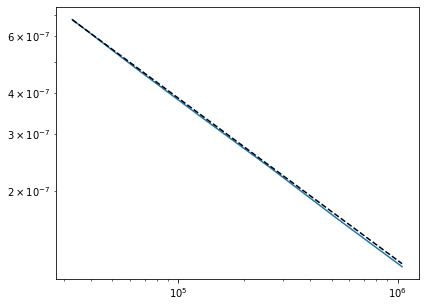

In [17]:
import matplotlib.pyplot as plt
fig, ax = plt.subplots(1, 1, figsize=(6.5,5))
prefix = 'testcorr'

x_pts = [2**exp for exp in range(15, 21)]
y_pts = []
for x in x_pts:
    results = torch.load(prefix+f"_P{x}.pt")
    y_pts.append(results['corr'].cpu())

ax.plot(x_pts, y_pts)

ax.plot(x_pts, [x**(-.5)/(vocab_size) for x in x_pts], 'k--')

ax.set_xscale('log')
ax.set_yscale('log')